# Single PPMI Subtyping Experiment

This notebook runs a single subtyping experiment on PPMI data and displays:
- Final LSE
- Histogram of beta values by subtype


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from EMDPM.subtyping_em_transformer import SubtypingEM
from EMDPM.utils import initialize_f_eigen, fit_mixedlm_beta_from_clinical, solve_system
from sklearn.model_selection import train_test_split

# Set random seed for reproducibility
np.random.seed(75)


In [2]:
# Load PPMI data
df = pd.read_csv("/data01/bgutman/MRI_data/PPMI/data_ppmi_pd.csv")
df_K = pd.read_csv("/data01/bgutman/LEGACY/Skoltech/datasets/Connectomes/mean_NORM_con_22.csv")
n_biomarkers = 68

print("Original size:", df.shape)

# Remove non-longitudinal observations
relevant_cols = [col for col in df.columns if col.startswith(('L_', 'R_')) and ('_thickavg' in col or '_thickavg_resid' in col)]
relevant_cols += ["MCATOT", "TD_score", "PIGD_score"]
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=relevant_cols)

print("After drop na:", df.shape)

subj_counts = df['subj_id'].value_counts()
longitudinal_ids = subj_counts[subj_counts > 1].index
df = df[df['subj_id'].isin(longitudinal_ids)].copy()
df = df.dropna(subset=relevant_cols)
df = df.drop_duplicates(subset=["subj_id", "time"])

print("After filtering:", df.shape)


Original size: (880, 250)
After drop na: (868, 250)
After filtering: (504, 250)


In [3]:
# Prepare biomarker data
X_obs = df[[col for col in df.columns if (col.startswith(('L_', 'R_')) and col.endswith('_thickavg') and not col.endswith('_thickavg_resid'))]]
X_obs = X_obs.to_numpy()
X_obs = np.max(X_obs, axis=0) - X_obs  # Invert so higher = worse

# Prepare connectivity matrix
K = df_K.drop(df_K.columns[0], axis=1).to_numpy()
np.fill_diagonal(K, 0)

# Normalize connectivity matrix
row_sums = K.sum(axis=1)
median_row_sum = np.median(row_sums)
K = K / median_row_sum

# Prepare other data
t_max = 40
ids = df["subj_id"].to_numpy()
dt = df["time"].to_numpy() / 12  # Convert to years
cog = df[["MCATOT", "TD_score", "PIGD_score"]].to_numpy()

print(f"Data shapes:")
print(f"  X_obs: {X_obs.shape}")
print(f"  K: {K.shape}")
print(f"  Unique patients: {len(np.unique(ids))}")
print(f"  Total observations: {len(ids)}")


Data shapes:
  X_obs: (504, 68)
  K: (68, 68)
  Unique patients: 146
  Total observations: 504


In [4]:
# Initialize beta from clinical scores
initial_beta, pid_to_beta, _ = fit_mixedlm_beta_from_clinical(
    df=df,
    ids=ids,
    dt=dt,
    t_max=t_max,
    verbose=True,
    rng=np.random.default_rng(75)
)

# Initialize f using eigenvectors
f_init_list = initialize_f_eigen(
    K=K,
    jitter_strength=0.05,
    n_eigs=100,
    rng=np.random.RandomState(75)
)
f_init = f_init_list[0]
f_init = np.ravel(f_init)

print(f"\nInitialized:")
print(f"  Beta range: [{np.min(initial_beta):.2f}, {np.max(initial_beta):.2f}]")
print(f"  Beta mean: {np.mean(initial_beta):.2f}")
print(f"  f_init shape: {f_init.shape}")


beta_init summary: count    146.000000
mean      15.622559
std        7.789749
min        0.000000
25%        9.586119
50%       15.547791
75%       20.682329
max       40.000000
dtype: float64

Initialized:
  Beta range: [0.00, 40.00]
  Beta mean: 15.62
  f_init shape: (68,)


In [5]:
# Create patient list format
def create_patient_list(X_obs, ids, dt, cog, initial_beta=None):
    unique_ids = np.unique(ids)
    id_to_index = {pid: idx for idx, pid in enumerate(unique_ids)}

    patient_list = []
    for pid in unique_ids:
        mask = (ids == pid)
        patient_data = {
            "id": pid,
            "X_obs": X_obs[mask],
            "dt": dt[mask],
            "cog": cog[mask]
        }
        if initial_beta is not None:
            patient_data["initial_beta"] = initial_beta[id_to_index[pid]]
        patient_list.append(patient_data)

    return patient_list

X = create_patient_list(X_obs, ids, dt, cog, initial_beta)
X_train, X_val = train_test_split(X, test_size=0.2, random_state=75)

print(f"Training patients: {len(X_train)}")
print(f"Validation patients: {len(X_val)}")


Training patients: 116
Validation patients: 30


In [6]:
# Set model parameters
# Using best parameters from multinit experiment
model_params = {
    "lambda_f": 0.65,
    "lambda_cog": 0.2,
    "lambda_scalar": 1.5,
    "lambda_jsd": 0.0,
    "lambda_beta": 0.0
}

print("Model parameters:")
for name, value in model_params.items():
    print(f"  {name}: {value}")


Model parameters:
  lambda_f: 0.65
  lambda_cog: 0.2
  lambda_scalar: 1.5
  lambda_jsd: 0.0
  lambda_beta: 0.0


In [7]:
# Initialize and fit the model
em = SubtypingEM(
    K=K,
    initial_f=f_init,
    n_subtypes=2,
    jac_toggle=True,
    max_iter=100,
    t_max=t_max,
    step=0.01,
    epsilon=1e0,
    lambda_f=model_params["lambda_f"],
    lambda_cog=model_params["lambda_cog"],
    lambda_scalar=model_params["lambda_scalar"],
    lambda_jsd=model_params["lambda_jsd"],
    lambda_beta=model_params["lambda_beta"],
    verbose=1
)

em.fit(X=X_train, y=None)

final_lse = em.lse_history[-1]
print(f"\n=== Results ===")
print(f"Final LSE: {final_lse:.6f}")
print(f"Initial LSE: {em.lse_history[0]:.6f}")
print(f"Number of iterations: {len(em.lse_history) - 1}")


  0%|          | 0/100 [00:00<?, ?it/s]

 35%|███▌      | 35/100 [13:53<25:47, 23.81s/it] 


=== Results ===
Final LSE: 745.491572
Initial LSE: 92748.676589
Number of iterations: 36


In [8]:
# Get beta values and assignments
beta_train = em.beta_history[:, -1]  # Final beta values
assignments = em.final_assignments

print(f"\nSubtype assignments:")
print(f"  Subtype 0: {np.sum(assignments == 0)} patients")
print(f"  Subtype 1: {np.sum(assignments == 1)} patients")

# Extract betas by subtype
beta_subtype0 = beta_train[assignments == 0]
beta_subtype1 = beta_train[assignments == 1]

print(f"\nBeta statistics:")
print(f"  Subtype 0 - Mean: {np.mean(beta_subtype0):.2f}, Std: {np.std(beta_subtype0):.2f}, Range: [{np.min(beta_subtype0):.2f}, {np.max(beta_subtype0):.2f}]")
print(f"  Subtype 1 - Mean: {np.mean(beta_subtype1):.2f}, Std: {np.std(beta_subtype1):.2f}, Range: [{np.min(beta_subtype1):.2f}, {np.max(beta_subtype1):.2f}]")



Subtype assignments:
  Subtype 0: 62 patients
  Subtype 1: 54 patients

Beta statistics:
  Subtype 0 - Mean: 6.22, Std: 0.96, Range: [4.31, 8.41]
  Subtype 1 - Mean: 26.74, Std: 1.79, Range: [23.35, 30.35]


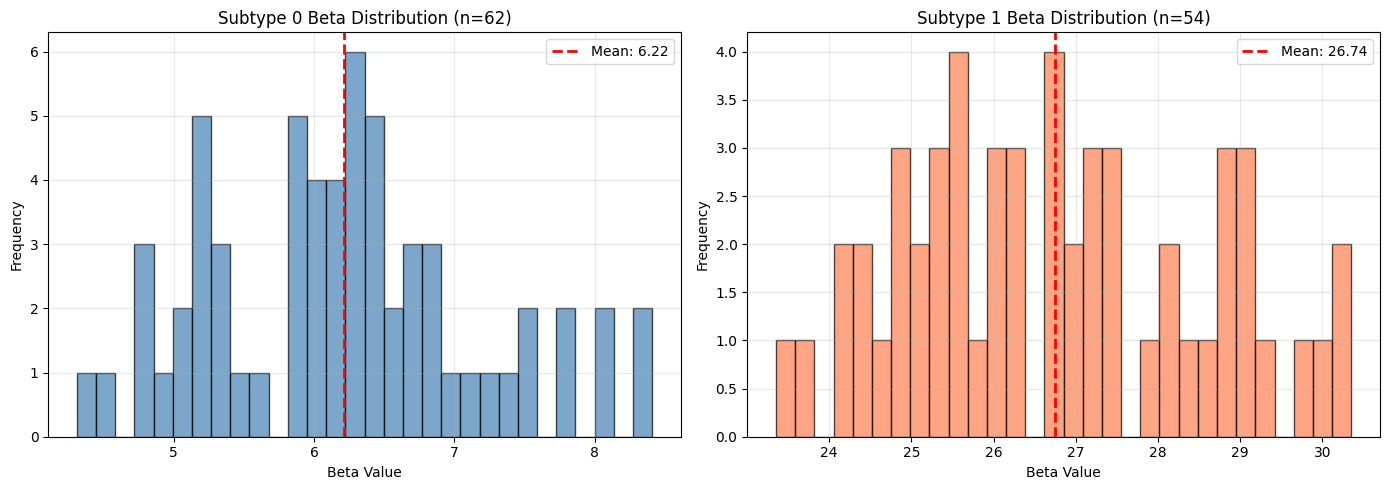

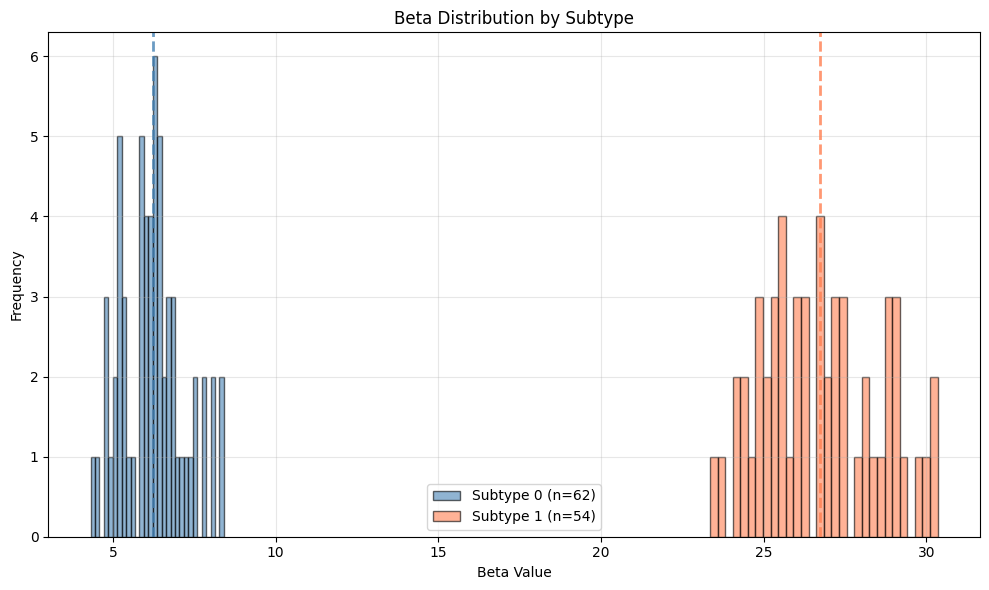

In [9]:
# Plot histogram of beta values by subtype
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram for Subtype 0
axes[0].hist(beta_subtype0, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(np.mean(beta_subtype0), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(beta_subtype0):.2f}')
axes[0].set_xlabel('Beta Value')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Subtype 0 Beta Distribution (n={len(beta_subtype0)})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram for Subtype 1
axes[1].hist(beta_subtype1, bins=30, alpha=0.7, color='coral', edgecolor='black')
axes[1].axvline(np.mean(beta_subtype1), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(beta_subtype1):.2f}')
axes[1].set_xlabel('Beta Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Subtype 1 Beta Distribution (n={len(beta_subtype1)})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Combined histogram
plt.figure(figsize=(10, 6))
plt.hist(beta_subtype0, bins=30, alpha=0.6, label=f'Subtype 0 (n={len(beta_subtype0)})', color='steelblue', edgecolor='black')
plt.hist(beta_subtype1, bins=30, alpha=0.6, label=f'Subtype 1 (n={len(beta_subtype1)})', color='coral', edgecolor='black')
plt.axvline(np.mean(beta_subtype0), color='steelblue', linestyle='--', linewidth=2, alpha=0.8)
plt.axvline(np.mean(beta_subtype1), color='coral', linestyle='--', linewidth=2, alpha=0.8)
plt.xlabel('Beta Value')
plt.ylabel('Frequency')
plt.title('Beta Distribution by Subtype')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


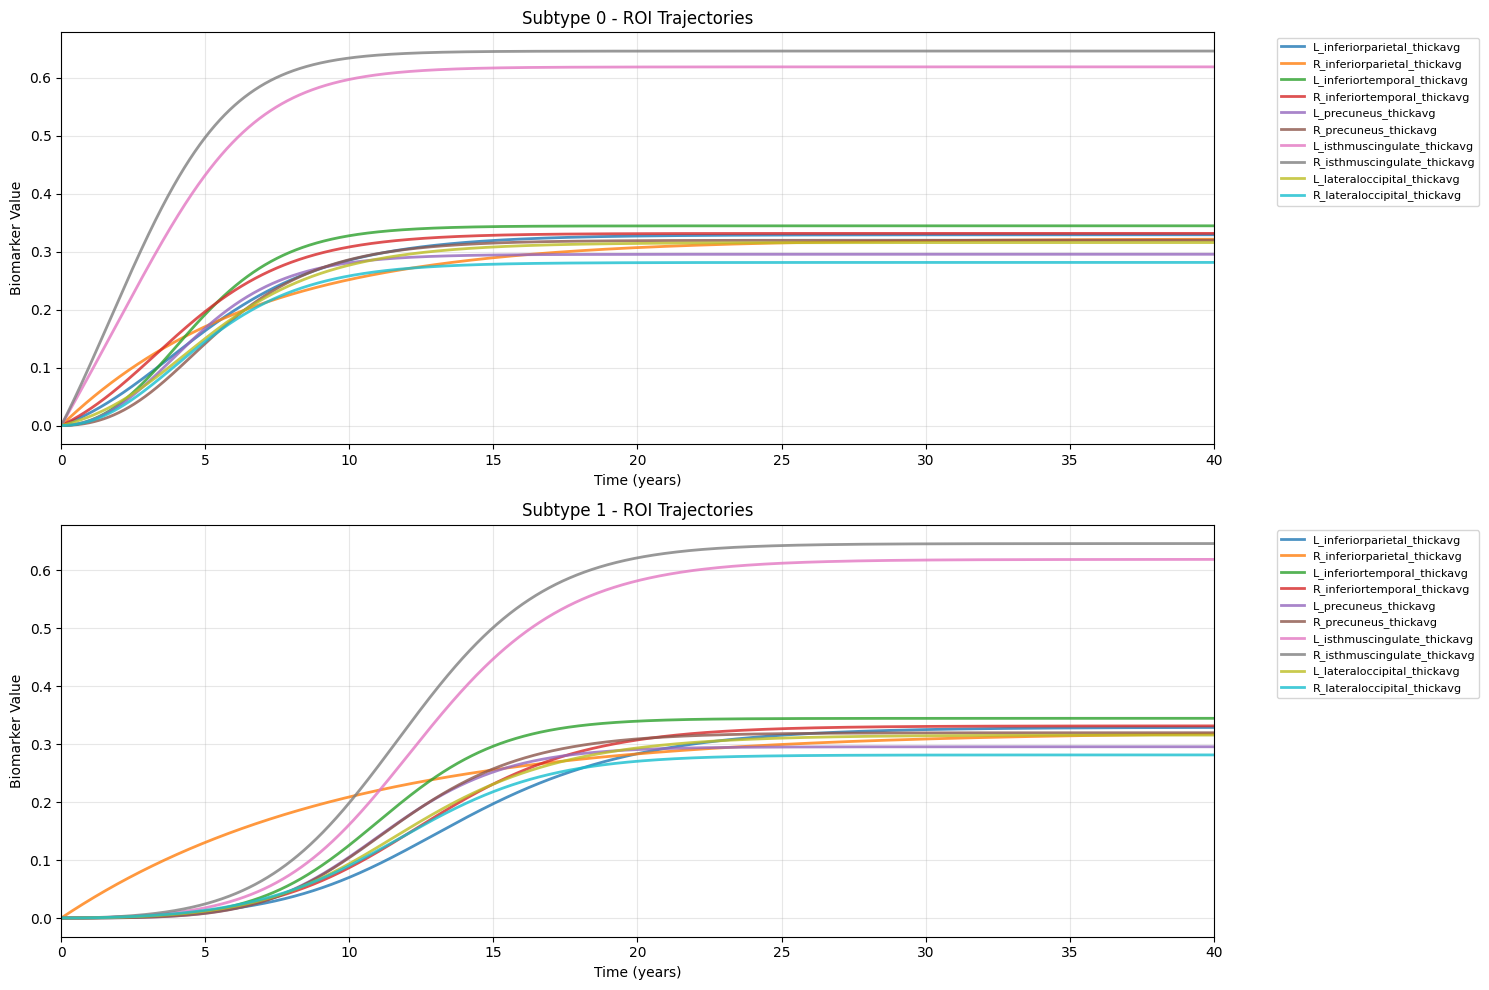

In [10]:
from EMDPM.utils import solve_system

# Plot 10 ROI trajectories for both subtypes
ROI = [6, 40, 7, 41, 23, 57, 8, 42, 9, 43]

# Get biomarker names
biomarker_names = [col for col in df.columns 
                   if col.startswith(('L_', 'R_')) and 
                   col.endswith('_thickavg') and 
                   not col.endswith('_thickavg_resid')]
ROI_names = [biomarker_names[i] for i in ROI]

# Extract cluster parameters from fitted model
cluster_f = em.cluster_f  # (n_subtypes, n_biomarkers)
n_subtypes = 2
n_biomarkers = 68

final_scalar_K = em.final_scalar_K
final_s = em.final_s
t_span = em.t_span

# Plot trajectories for each subtype
fig, axes = plt.subplots(n_subtypes, 1, figsize=(15, 5*n_subtypes))
if n_subtypes == 1:
    axes = [axes]

for subtype in range(n_subtypes):
    f_subtype = cluster_f[subtype]
    x0 = np.zeros(n_biomarkers)
    Xtraj_subtype = solve_system(x0, f_subtype, K, t_span, final_scalar_K) * final_s[:, None]
    
    ax = axes[subtype]
    for i, roi_idx in enumerate(ROI):
        ax.plot(t_span, Xtraj_subtype[roi_idx], label=ROI_names[i], linewidth=2, alpha=0.8)
    
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Biomarker Value")
    ax.set_title(f"Subtype {subtype} - ROI Trajectories")
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, t_max)

plt.tight_layout()
plt.show()
